In [ ]:
import pandas as pd

df = pd.read_csv("/Users/srujanakasipuram/Downloads/PS_20174392719_1491204439457_log.csv")

df = df[df["type"].isin(["PAYMENT", "CASH_OUT"])]

df["type"] = df["type"].map({"PAYMENT": 0, "CASH_OUT": 1})

df = df[
    [
        "step", "type", "amount",
        "nameOrig", "oldbalanceOrg", "newbalanceOrig",
        "nameDest", "oldbalanceDest", "newbalanceDest",
        "isFraud"
    ]
]

df = df.sample(200000, random_state=42)

df.to_csv("/Users/srujanakasipuram/Documents/Project/clean_data.csv", index=False)

print("Clean dataset saved")

df = pd.read_csv("/Users/srujanakasipuram/Documents/Project/clean_data.csv")


train = df[df["step"] <= df["step"].quantile(0.8)]
test = df[df["step"] > df["step"].quantile(0.8)]

train.to_csv("/Users/srujanakasipuram/Documents/Project/train_data.csv", index=False)
test.to_csv("/Users/srujanakasipuram/Documents/Project/test_data.csv", index=False)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("/Users/srujanakasipuram/Documents/Project/clean_data.csv")

print(df.shape)
df.head()

df.info()


df["isFraud"].value_counts()


fraud_ratio = df["isFraud"].mean()
fraud_ratio


sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()


df["type"].value_counts()



sns.countplot(y="type", data=df, order=df["type"].value_counts().index)
plt.title("Transaction Types")
plt.show()

df.groupby("type")["isFraud"].mean().sort_values(ascending=False)


plt.figure(figsize=(8,4))
sns.histplot(df["amount"], bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x="isFraud", y="amount", data=df)
plt.yscale("log")
plt.title("Amount vs Fraud")
plt.show()



df["balance_error"] = (
    df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
).abs()

sns.boxplot(x="isFraud", y="balance_error", data=df)
plt.yscale("log")
plt.title("Balance Error vs Fraud")
plt.show()



df["nameOrig"].nunique(), df["nameDest"].nunique()



fraud_df = df[df["isFraud"] == 1]

fraud_df["nameOrig"].value_counts().head(10)



plt.figure(figsize=(10,4))
df.groupby("step")["isFraud"].mean().plot()
plt.title("Fraud Rate Over Time")
plt.xlabel("Time Step (Hours)")
plt.ylabel("Fraud Rate")
plt.show()



numeric_cols = [
    "step", "amount",
    "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "isFraud"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()





import torch
print(torch.__version__)




import torch
from torch_geometric.data import Data

print(torch.__version__)
print("PyG ready")


import pandas as pd
import torch
from torch_geometric.data import Data


df = pd.read_csv("/Users/srujanakasipuram/Documents/Project/train_data.csv")

accounts = pd.concat([df["nameOrig"], df["nameDest"]]).unique()
transactions = df.index.astype(str)

account_nodes = [f"acc_{a}" for a in accounts]
transaction_nodes = [f"tx_{i}" for i in transactions]

all_nodes = account_nodes + transaction_nodes
node_id_map = {node: idx for idx, node in enumerate(all_nodes)}


x = []

for _ in account_nodes:
    x.append([0.0, 0.0, 0.0])

for _, row in df.iterrows():
    x.append([
        row["amount"],
        row["type"],
        row["oldbalanceOrg"] - row["newbalanceOrig"]
    ])

x = torch.tensor(x, dtype=torch.float)

y = torch.zeros(len(all_nodes), dtype=torch.long)

for i, row in df.iterrows():
    y[node_id_map[f"tx_{i}"]] = row["isFraud"]


edge_index = []

for i, row in df.iterrows():
    edge_index.append([
        node_id_map[f"acc_{row['nameOrig']}"],
        node_id_map[f"tx_{i}"]
    ])
    edge_index.append([
        node_id_map[f"tx_{i}"],
        node_id_map[f"acc_{row['nameDest']}"]
    ])

edge_index = torch.tensor(edge_index, dtype=torch.long).t()

graph = Data(x=x, edge_index=edge_index, y=y)

print(graph)

graph.x.shape, graph.edge_index.shape, graph.y.shape

print("Fraud count:", graph.y.sum().item())
print("Total nodes:", graph.y.numel())
print("Fraud ratio:", graph.y.float().mean().item())

import torch

torch.save(graph, "/Users/srujanakasipuram/Documents/Project/graph.pt")



import torch
import networkx as nx
import matplotlib.pyplot as plt
import random

import torch

graph = torch.load(
    "/Users/srujanakasipuram/Documents/Project/graph.pt",
    weights_only=False
)

print(graph)

print(type(graph))
print(graph.x.shape)
print(graph.edge_index.shape)
print(graph.y.float().mean())

import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

import torch

graph = torch.load(
    "/Users/srujanakasipuram/Documents/Project/graph.pt",
    weights_only=False
)

print(graph)



tx_mask = graph.x[:, 0] > 0

print("Transaction nodes:", tx_mask.sum().item())
print("Fraud tx:", graph.y[tx_mask].sum().item())



tx_indices = tx_mask.nonzero(as_tuple=True)[0]
tx_indices = tx_indices[torch.randperm(len(tx_indices))]

split = int(0.8 * len(tx_indices))
train_idx = tx_indices[:split]
val_idx = tx_indices[split:]

graph.train_mask = torch.zeros(graph.num_nodes, dtype=torch.bool)
graph.val_mask = torch.zeros(graph.num_nodes, dtype=torch.bool)

graph.train_mask[train_idx] = True
graph.val_mask[val_idx] = True




num_fraud = graph.y[graph.train_mask].sum()
num_legit = graph.train_mask.sum() - num_fraud

pos_weight = num_legit / num_fraud
pos_weight



class AdvancedFraudGNN(torch.nn.Module):
    def __init__(self, in_dim):
        super().__init__()

        self.conv1 = SAGEConv(in_dim, 128)
        self.bn1 = torch.nn.BatchNorm1d(128)

        self.conv2 = SAGEConv(128, 128)
        self.bn2 = torch.nn.BatchNorm1d(128)

        self.conv3 = SAGEConv(128, 64)
        self.bn3 = torch.nn.BatchNorm1d(64)

        self.conv4 = SAGEConv(64, 32)

        self.out = torch.nn.Linear(32, 1)

    def forward(self, x, edge_index):
        h1 = F.relu(self.bn1(self.conv1(x, edge_index)))
        h1 = F.dropout(h1, p=0.4, training=self.training)

        h2 = F.relu(self.bn2(self.conv2(h1, edge_index)))
        h2 = h2 + h1  # residual connection
        h2 = F.dropout(h2, p=0.4, training=self.training)

        h3 = F.relu(self.bn3(self.conv3(h2, edge_index)))
        h3 = F.dropout(h3, p=0.3, training=self.training)

        h4 = F.relu(self.conv4(h3, edge_index))

        return self.out(h4).squeeze()



model = AdvancedFraudGNN(graph.x.size(1))
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

loss_fn = torch.nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)



best_auc = 0
patience = 5
counter = 0
epochs = 50

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    logits = model(graph.x, graph.edge_index)

    loss = loss_fn(
        logits[graph.train_mask],
        graph.y[graph.train_mask].float()
    )

    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(logits)

        y_true = graph.y[graph.val_mask].cpu().numpy()
        y_pred = probs[graph.val_mask].cpu().numpy()

        roc_auc = roc_auc_score(y_true, y_pred)
        pr_auc = average_precision_score(y_true, y_pred)

    print(
        f"Epoch {epoch:02d} | "
        f"Loss {loss.item():.4f} | "
        f"ROC-AUC {roc_auc:.4f} | "
        f"PR-AUC {pr_auc:.4f}"
    )

    
    if roc_auc > best_auc:
        best_auc = roc_auc
        counter = 0
        torch.save(model.state_dict(), "/Users/srujanakasipuram/Documents/Project/best_fraud_gnn.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break



model.load_state_dict(torch.load("/Users/srujanakasipuram/Documents/Project/best_fraud_gnn.pt"))
model.eval()
print("Best model loaded")



import torch

class FraudPredictor:
    def __init__(self):
        self.graph = torch.load(
            "/Users/srujanakasipuram/Documents/Project/graph.pt",
            weights_only=False
        )

        self.model = AdvancedFraudGNN(self.graph.x.size(1))
        self.model.load_state_dict(
            torch.load("/Users/srujanakasipuram/Documents/Project/best_fraud_gnn.pt", map_location="cpu")
        )
        self.model.eval()

        with torch.no_grad():
            self.cached_logits = self.model(
                self.graph.x,
                self.graph.edge_index
            )

    def predict(self, node_id: int):
        prob = torch.sigmoid(self.cached_logits[node_id]).item()
        return prob



test_graph = torch.load(
    "/Users/srujanakasipuram/Documents/Project/graph.pt",
    weights_only=False
)


test_tx_mask = test_graph.x[:, 0] > 0



model.eval()
with torch.no_grad():
    test_logits = model(
        test_graph.x,
        test_graph.edge_index
    )
    test_probs = torch.sigmoid(test_logits)



from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

y_true = test_graph.y[test_tx_mask].cpu().numpy()
y_pred = test_probs[test_tx_mask].cpu().numpy()

print("TEST ROC-AUC:", roc_auc_score(y_true, y_pred))
print("TEST PR-AUC:", average_precision_score(y_true, y_pred))
print(classification_report(y_true, y_pred > 0.7))



def predict_transaction(node_id):
    model.eval()
    with torch.no_grad():
        logit = model(graph.x, graph.edge_index)[node_id]
        prob = torch.sigmoid(logit).item()
    return {
        "fraud_probability": prob,
        "is_fraud": prob >= 0.7
    }

predict_transaction(11345)

def explain_transaction(graph, node_id, k=10):
    """
    Explains a transaction by showing its graph neighbors
    """
    
    mask_src = graph.edge_index[0] == node_id
    mask_dst = graph.edge_index[1] == node_id

    neighbors = torch.cat([
        graph.edge_index[1][mask_src],
        graph.edge_index[0][mask_dst]
    ])

    neighbors = neighbors.unique()[:k]

    explanation = {
        "transaction_node": node_id,
        "num_neighbors": neighbors.numel(),
        "neighbor_nodes": neighbors.tolist(),
        "neighbor_fraud_labels": graph.y[neighbors].tolist()
    }

    return explanation



class FraudPredictor:
    def __init__(self, model, graph):
        self.model = model
        self.graph = graph

        self.model.eval()
        with torch.no_grad():
            self.logits = self.model(
                self.graph.x,
                self.graph.edge_index
            )
            self.probs = torch.sigmoid(self.logits)

    def predict(self, node_id: int):
        if node_id < 0 or node_id >= self.graph.num_nodes:
            return {"error": "Invalid node_id"}

        score = self.probs[node_id].item()

        return {
            "node_id": node_id,
            "fraud_probability": round(score, 4),
            "is_fraud": score >= 0.7
        }



predictor = FraudPredictor(model, graph)
print("Predictor initialized successfully")




fraud_node = (graph.y == 1).nonzero(as_tuple=True)[0][0].item()

prediction = predictor.predict(fraud_node)
explanation = explain_transaction(graph, fraud_node)

prediction, explanation



from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

y_true = test_graph.y[test_tx_mask].cpu().numpy()
y_pred = test_probs[test_tx_mask].cpu().numpy()

print("TEST ROC-AUC :", roc_auc_score(y_true, y_pred))
print("TEST PR-AUC  :", average_precision_score(y_true, y_pred))
print(classification_report(y_true, y_pred > 0.7))

from flask import Flask, request, jsonify
from flask_cors import CORS
from datetime import datetime

app = Flask(__name__)
CORS(app)

# -------------------------------
# HEALTH CHECK
# -------------------------------
@app.route("/", methods=["GET"])
def health():
    return jsonify({
        "status": "running",
        "service": "Fraud Detection API",
        "time": datetime.utcnow().isoformat()
    })


# -------------------------------
# SINGLE PREDICTION
# -------------------------------
@app.route("/predict", methods=["POST"])
def api_predict():
    try:
        data = request.get_json()

        if not data or "node_id" not in data:
            return jsonify({
                "error": "node_id is required"
            }), 400

        node_id = int(data["node_id"])

        result = predict_transaction(node_id)

        if "error" in result:
            return jsonify(result), 400

        return jsonify({
            "node_id": node_id,
            "prediction": result["is_fraud"],
            "fraud_probability": result["fraud_probability"],
            "risk_level": (
                "HIGH" if result["fraud_probability"] > 0.8 else
                "MEDIUM" if result["fraud_probability"] > 0.5 else
                "LOW"
            ),
            "timestamp": datetime.utcnow().isoformat()
        })

    except Exception as e:
        return jsonify({
            "error": "Internal server error",
            "details": str(e)
        }), 500


# -------------------------------
# PREDICTION + EXPLANATION
# -------------------------------
@app.route("/predict/explain", methods=["POST"])
def api_predict_explain():
    try:
        data = request.get_json()
        node_id = int(data.get("node_id", -1))

        if node_id < 0:
            return jsonify({"error": "Invalid node_id"}), 400

        prediction = predict_transaction(node_id)
        explanation = explain_transaction(graph, node_id)

        return jsonify({
            "node_id": node_id,
            "fraud_probability": prediction["fraud_probability"],
            "is_fraud": prediction["is_fraud"],
            "explanation": explanation
        })

    except Exception as e:
        return jsonify({
            "error": str(e)
        }), 500


# -------------------------------
# BATCH PREDICTION
# -------------------------------
@app.route("/predict/batch", methods=["POST"])
def api_predict_batch():
    try:
        data = request.get_json()
        node_ids = data.get("node_ids", [])

        if not isinstance(node_ids, list):
            return jsonify({"error": "node_ids must be a list"}), 400

        results = []
        for nid in node_ids:
            pred = predict_transaction(int(nid))
            results.append({
                "node_id": nid,
                "fraud_probability": pred["fraud_probability"],
                "is_fraud": pred["is_fraud"]
            })

        return jsonify({
            "count": len(results),
            "results": results
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500


# -------------------------------
# MODEL INFO
# -------------------------------
@app.route("/model/info", methods=["GET"])
def model_info():
    return jsonify({
        "model": "Graph Neural Network (GraphSAGE)",
        "task": "Online Fraud Detection",
        "node_type": "Transaction Nodes",
        "output": "Fraud Probability",
        "threshold": 0.7
    })


# -------------------------------
# SERVER START
# -------------------------------
if __name__ == "__main__":
    print("🚀 Advanced Fraud Detection API running...")
    app.run(host="0.0.0.0", port=5001, debug=True)

Clean dataset saved


In [ ]:
df = pd.read_csv("/Users/shanks/clean_data.csv")

In [ ]:
train = df[df["step"] <= df["step"].quantile(0.8)]
test = df[df["step"] > df["step"].quantile(0.8)]

train.to_csv("train_data.csv", index=False)
test.to_csv("test_data.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Load dataset
df = pd.read_csv("/Users/shanks/clean_data.csv")

print(df.shape)
df.head()

(200000, 10)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,188,0,448.89,C1376043704,107230.0,106781.11,M804859561,0.0,0.00,0
1,181,0,17871.93,C60417378,0.0,0.00,M699369321,0.0,0.00,0
2,255,1,10687.94,C1045626224,852761.0,842073.06,C1689141341,0.0,10687.94,0
3,139,0,15695.20,C1730636795,367.0,0.00,M1769049983,0.0,0.00,0
4,141,1,28542.70,C484402723,682.0,0.00,C286423521,0.0,28542.70,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   type            200000 non-null  int64  
 2   amount          200000 non-null  float64
 3   nameOrig        200000 non-null  object 
 4   oldbalanceOrg   200000 non-null  float64
 5   newbalanceOrig  200000 non-null  float64
 6   nameDest        200000 non-null  object 
 7   oldbalanceDest  200000 non-null  float64
 8   newbalanceDest  200000 non-null  float64
 9   isFraud         200000 non-null  int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 15.3+ MB


In [ ]:
df["isFraud"].value_counts()

isFraud
0    199812
1       188
Name: count, dtype: int64

In [ ]:
fraud_ratio = df["isFraud"].mean()
fraud_ratio

np.float64(0.00094)

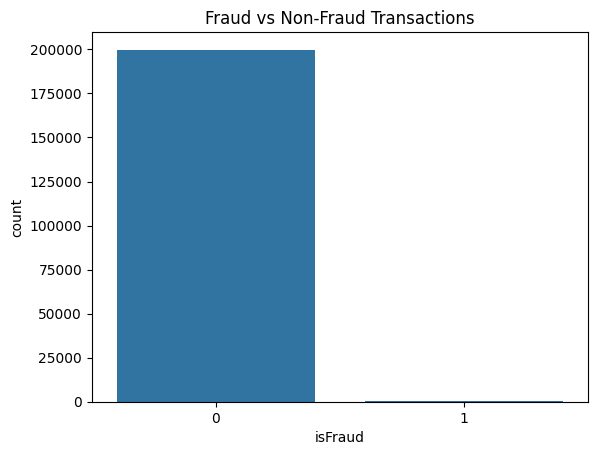

In [ ]:
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [ ]:
df["type"].value_counts()

type
1    101834
0     98166
Name: count, dtype: int64

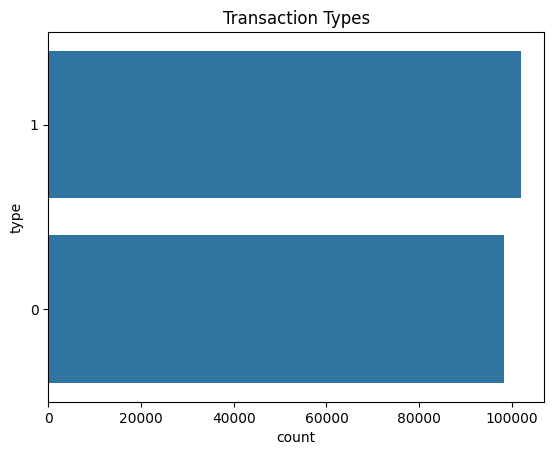

In [ ]:
sns.countplot(y="type", data=df, order=df["type"].value_counts().index)
plt.title("Transaction Types")
plt.show()

In [ ]:
df.groupby("type")["isFraud"].mean().sort_values(ascending=False)

type
1    0.001846
0    0.000000
Name: isFraud, dtype: float64

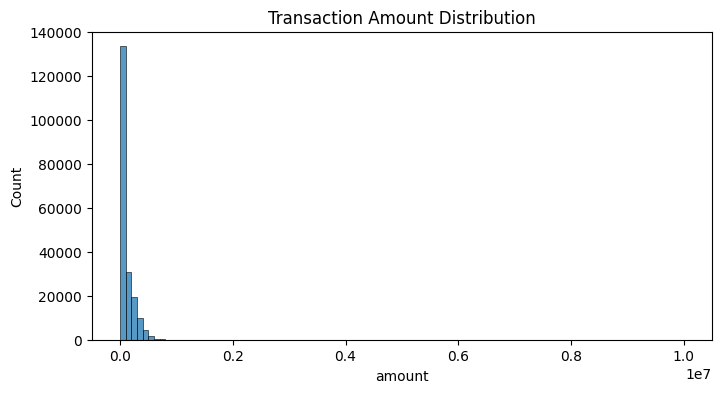

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df["amount"], bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

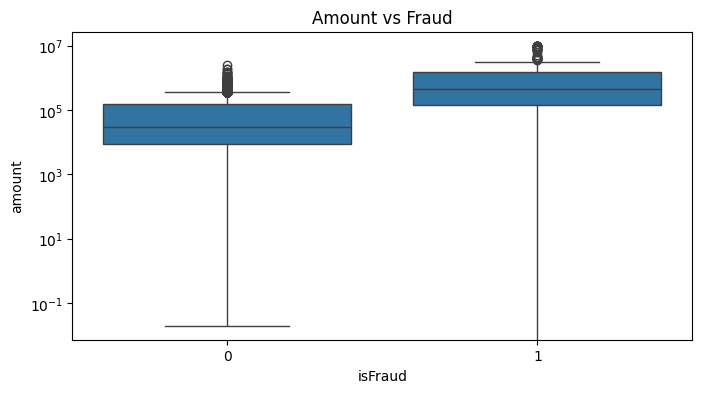

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x="isFraud", y="amount", data=df)
plt.yscale("log")
plt.title("Amount vs Fraud")
plt.show()

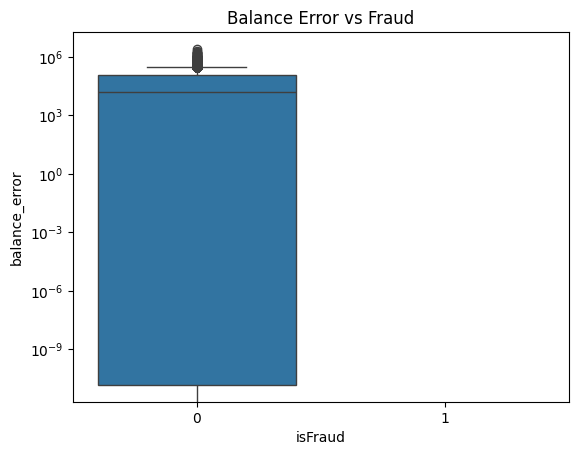

In [ ]:
df["balance_error"] = (
    df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
).abs()

sns.boxplot(x="isFraud", y="balance_error", data=df)
plt.yscale("log")
plt.title("Balance Error vs Fraud")
plt.show()

In [ ]:
df["nameOrig"].nunique(), df["nameDest"].nunique()

(199991, 184431)

In [ ]:
fraud_df = df[df["isFraud"] == 1]

fraud_df["nameOrig"].value_counts().head(10)

nameOrig
C1510732148    1
C1880773458    1
C1926290864    1
C319563760     1
C1122962082    1
C442653315     1
C587736003     1
C21772807      1
C1711085884    1
C1241305776    1
Name: count, dtype: int64

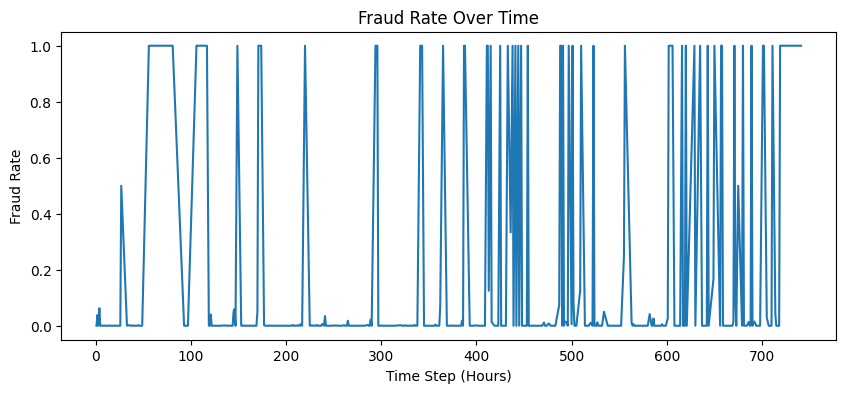

In [ ]:
plt.figure(figsize=(10,4))
df.groupby("step")["isFraud"].mean().plot()
plt.title("Fraud Rate Over Time")
plt.xlabel("Time Step (Hours)")
plt.ylabel("Fraud Rate")
plt.show()

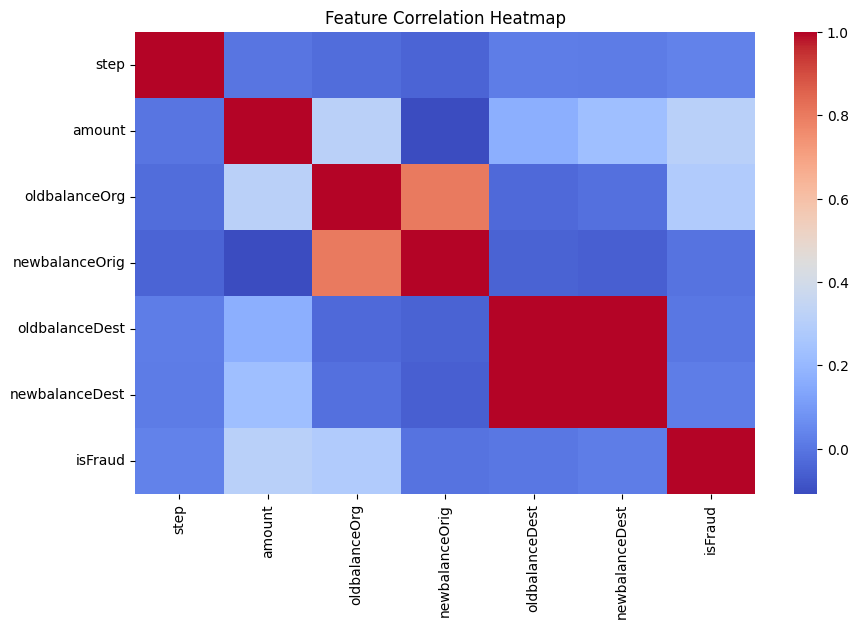

In [ ]:
numeric_cols = [
    "step", "amount",
    "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "isFraud"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
!pip install torch torchvision torchaudio

  Obtaining dependency information for torch from https://files.pythonhosted.org/packages/0f/8b/4b61d6e13f7108f36910df9ab4b58fd389cc2520d54d81b88660804aad99/torch-2.10.0-2-cp311-none-macosx_11_0_arm64.whl.metadata
  Using cached torch-2.10.0-2-cp311-none-macosx_11_0_arm64.whl.metadata (31 kB)
  Obtaining dependency information for torchvision from https://files.pythonhosted.org/packages/3e/be/c704bceaf11c4f6b19d64337a34a877fcdfe3bd68160a8c9ae9bea4a35a3/torchvision-0.25.0-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for torchaudio from https://files.pythonhosted.org/packages/5c/e7/401fe1d024bf9352371d854be6f339ad9928669e6bc8a5ba08e9dbce81cf/torchaudio-2.10.0-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for sympy>=1.13.3 from https://files.pythonhosted.org/packages/a2/09/77d55d46fd61b4a135c444fc97158ef34a095e5681d0a6c10b75bf356191/sympy-1.14.0-py3-none-any.whl.metadata
  Using cached sympy-1.14.0-py3-none-any.whl.metadata 

In [ ]:
import torch
print(torch.__version__)

2.10.0


In [ ]:
!pip install torch-geometric

  Obtaining dependency information for torch-geometric from https://files.pythonhosted.org/packages/1e/d3/4dffd7300500465e0b4a2ae917dcb2ce771de0b9a772670365799a27c024/torch_geometric-2.7.0-py3-none-any.whl.metadata
  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
  Obtaining dependency information for xxhash from https://files.pythonhosted.org/packages/5e/ec/1cc11cd13e26ea8bc3cb4af4eaadd8d46d5014aebb67be3f71fb0b68802a/xxhash-3.6.0-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Using cached xxhash-3.6.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (13 kB)
Using cached torch_geometric-2.7.0-py3-none-any.whl (1.3 MB)
Using cached xxhash-3.6.0-cp311-cp311-macosx_11_0_arm64.whl (30 kB)


In [ ]:
import torch
from torch_geometric.data import Data

print(torch.__version__)
print("PyG ready")

2.10.0
PyG ready


In [ ]:
import pandas as pd
import torch
from torch_geometric.data import Data

# Load train data
df = pd.read_csv("/Users/shanks/train_data.csv")

# --------------------
# CREATE NODES
# --------------------
accounts = pd.concat([df["nameOrig"], df["nameDest"]]).unique()
transactions = df.index.astype(str)

account_nodes = [f"acc_{a}" for a in accounts]
transaction_nodes = [f"tx_{i}" for i in transactions]

all_nodes = account_nodes + transaction_nodes
node_id_map = {node: idx for idx, node in enumerate(all_nodes)}

# --------------------
# NODE FEATURES
# --------------------
x = []

# Account nodes (dummy features for now)
for _ in account_nodes:
    x.append([0.0, 0.0, 0.0])

# Transaction nodes
for _, row in df.iterrows():
    x.append([
        row["amount"],
        row["type"],
        row["oldbalanceOrg"] - row["newbalanceOrig"]
    ])

x = torch.tensor(x, dtype=torch.float)

# --------------------
# LABELS
# --------------------
y = torch.zeros(len(all_nodes), dtype=torch.long)

for i, row in df.iterrows():
    y[node_id_map[f"tx_{i}"]] = row["isFraud"]

# --------------------
# EDGES
# --------------------
edge_index = []

for i, row in df.iterrows():
    edge_index.append([
        node_id_map[f"acc_{row['nameOrig']}"],
        node_id_map[f"tx_{i}"]
    ])
    edge_index.append([
        node_id_map[f"tx_{i}"],
        node_id_map[f"acc_{row['nameDest']}"]
    ])

edge_index = torch.tensor(edge_index, dtype=torch.long).t()

# --------------------
# GRAPH OBJECT
# --------------------
graph = Data(x=x, edge_index=edge_index, y=y)

print(graph)

Data(x=[470980, 3], edge_index=[2, 322358], y=[470980])


In [ ]:
graph.x.shape, graph.edge_index.shape, graph.y.shape

(torch.Size([470980, 3]), torch.Size([2, 322358]), torch.Size([470980]))

In [ ]:
print("Fraud count:", graph.y.sum().item())
print("Total nodes:", graph.y.numel())
print("Fraud ratio:", graph.y.float().mean().item())

Fraud count: 84
Total nodes: 470980
Fraud ratio: 0.00017835151811596006


In [ ]:
import torch

torch.save(graph, "/Users/shanks/train_graph.pt")

In [ ]:
!pip install networkx

In [ ]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
import random

In [ ]:
import torch

graph = torch.load(
    "/Users/shanks/train_graph.pt",
    weights_only=False
)

print(graph)

Data(x=[470980, 3], edge_index=[2, 322358], y=[470980])


In [ ]:
print(type(graph))
print(graph.x.shape)
print(graph.edge_index.shape)
print(graph.y.float().mean())

<class 'torch_geometric.data.data.Data'>
torch.Size([470980, 3])
torch.Size([2, 322358])
tensor(0.0002)


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

In [ ]:
import torch

graph = torch.load(
    "/Users/shanks/train_graph.pt",
    weights_only=False
)

print(graph)

Data(x=[470980, 3], edge_index=[2, 322358], y=[470980])


In [ ]:
# Transaction nodes have non-zero features in column 0 (amount)
tx_mask = graph.x[:, 0] > 0

print("Transaction nodes:", tx_mask.sum().item())
print("Fraud tx:", graph.y[tx_mask].sum().item())

Transaction nodes: 161178
Fraud tx: 83


In [ ]:
tx_indices = tx_mask.nonzero(as_tuple=True)[0]
tx_indices = tx_indices[torch.randperm(len(tx_indices))]

split = int(0.8 * len(tx_indices))
train_idx = tx_indices[:split]
val_idx = tx_indices[split:]

graph.train_mask = torch.zeros(graph.num_nodes, dtype=torch.bool)
graph.val_mask = torch.zeros(graph.num_nodes, dtype=torch.bool)

graph.train_mask[train_idx] = True
graph.val_mask[val_idx] = True

In [ ]:
num_fraud = graph.y[graph.train_mask].sum()
num_legit = graph.train_mask.sum() - num_fraud

pos_weight = num_legit / num_fraud
pos_weight

tensor(2013.7188)

In [ ]:
class AdvancedFraudGNN(torch.nn.Module):
    def __init__(self, in_dim):
        super().__init__()

        self.conv1 = SAGEConv(in_dim, 128)
        self.bn1 = torch.nn.BatchNorm1d(128)

        self.conv2 = SAGEConv(128, 128)
        self.bn2 = torch.nn.BatchNorm1d(128)

        self.conv3 = SAGEConv(128, 64)
        self.bn3 = torch.nn.BatchNorm1d(64)

        self.conv4 = SAGEConv(64, 32)

        self.out = torch.nn.Linear(32, 1)

    def forward(self, x, edge_index):
        h1 = F.relu(self.bn1(self.conv1(x, edge_index)))
        h1 = F.dropout(h1, p=0.4, training=self.training)

        h2 = F.relu(self.bn2(self.conv2(h1, edge_index)))
        h2 = h2 + h1  # residual connection
        h2 = F.dropout(h2, p=0.4, training=self.training)

        h3 = F.relu(self.bn3(self.conv3(h2, edge_index)))
        h3 = F.dropout(h3, p=0.3, training=self.training)

        h4 = F.relu(self.conv4(h3, edge_index))

        return self.out(h4).squeeze()

In [ ]:
model = AdvancedFraudGNN(graph.x.size(1))
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

loss_fn = torch.nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

In [ ]:
best_auc = 0
patience = 5
counter = 0
epochs = 50

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    logits = model(graph.x, graph.edge_index)

    loss = loss_fn(
        logits[graph.train_mask],
        graph.y[graph.train_mask].float()
    )

    loss.backward()
    optimizer.step()

    # ---- VALIDATION ----
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(logits)

        y_true = graph.y[graph.val_mask].cpu().numpy()
        y_pred = probs[graph.val_mask].cpu().numpy()

        roc_auc = roc_auc_score(y_true, y_pred)
        pr_auc = average_precision_score(y_true, y_pred)

    print(
        f"Epoch {epoch:02d} | "
        f"Loss {loss.item():.4f} | "
        f"ROC-AUC {roc_auc:.4f} | "
        f"PR-AUC {pr_auc:.4f}"
    )

    # Early stopping
    if roc_auc > best_auc:
        best_auc = roc_auc
        counter = 0
        torch.save(model.state_dict(), "best_fraud_gnn.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

Epoch 00 | Loss 0.9449 | ROC-AUC 0.9478 | PR-AUC 0.4467
Epoch 01 | Loss 0.9460 | ROC-AUC 0.9471 | PR-AUC 0.4585
Epoch 02 | Loss 0.9289 | ROC-AUC 0.9505 | PR-AUC 0.4528
Epoch 03 | Loss 0.9014 | ROC-AUC 0.9544 | PR-AUC 0.3868
Epoch 04 | Loss 0.8961 | ROC-AUC 0.9699 | PR-AUC 0.4383
Epoch 05 | Loss 0.8769 | ROC-AUC 0.9675 | PR-AUC 0.4467
Epoch 06 | Loss 0.8706 | ROC-AUC 0.9594 | PR-AUC 0.4088
Epoch 07 | Loss 0.8632 | ROC-AUC 0.9585 | PR-AUC 0.3777
Epoch 08 | Loss 0.8336 | ROC-AUC 0.9665 | PR-AUC 0.4418
Epoch 09 | Loss 0.8375 | ROC-AUC 0.9595 | PR-AUC 0.3839
Early stopping triggered


In [ ]:
model.load_state_dict(torch.load("best_fraud_gnn.pt"))
model.eval()
print("Best model loaded")

Best model loaded


In [ ]:
import torch

class FraudPredictor:
    def __init__(self):
        self.graph = torch.load(
            "data/graph.pt",
            weights_only=False
        )

        self.model = AdvancedFraudGNN(self.graph.x.size(1))
        self.model.load_state_dict(
            torch.load("best_fraud_gnn.pt", map_location="cpu")
        )
        self.model.eval()

        with torch.no_grad():
            self.cached_logits = self.model(
                self.graph.x,
                self.graph.edge_index
            )

    def predict(self, node_id: int):
        prob = torch.sigmoid(self.cached_logits[node_id]).item()
        return prob

In [ ]:
test_graph = torch.load(
    "/Users/shanks/train_graph.pt",
    weights_only=False
)

In [ ]:
test_tx_mask = test_graph.x[:, 0] > 0

In [ ]:
model.eval()
with torch.no_grad():
    test_logits = model(
        test_graph.x,
        test_graph.edge_index
    )
    test_probs = torch.sigmoid(test_logits)

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

y_true = test_graph.y[test_tx_mask].cpu().numpy()
y_pred = test_probs[test_tx_mask].cpu().numpy()

print("TEST ROC-AUC:", roc_auc_score(y_true, y_pred))
print("TEST PR-AUC:", average_precision_score(y_true, y_pred))
print(classification_report(y_true, y_pred > 0.7))

TEST ROC-AUC: 0.9404742468430474
TEST PR-AUC: 0.46310179690683784
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    161095
           1       0.02      0.63      0.04        83

    accuracy                           0.98    161178
   macro avg       0.51      0.81      0.52    161178
weighted avg       1.00      0.98      0.99    161178



In [ ]:
def predict_transaction(node_id):
    model.eval()
    with torch.no_grad():
        logit = model(graph.x, graph.edge_index)[node_id]
        prob = torch.sigmoid(logit).item()
    return {
        "fraud_probability": prob,
        "is_fraud": prob >= 0.7
    }

predict_transaction(11345)

{'fraud_probability': 0.47253406047821045, 'is_fraud': False}

In [ ]:
def explain_transaction(graph, node_id, k=10):
    """
    Explains a transaction by showing its graph neighbors
    """
    # Find neighbors
    mask_src = graph.edge_index[0] == node_id
    mask_dst = graph.edge_index[1] == node_id

    neighbors = torch.cat([
        graph.edge_index[1][mask_src],
        graph.edge_index[0][mask_dst]
    ])

    neighbors = neighbors.unique()[:k]

    explanation = {
        "transaction_node": node_id,
        "num_neighbors": neighbors.numel(),
        "neighbor_nodes": neighbors.tolist(),
        "neighbor_fraud_labels": graph.y[neighbors].tolist()
    }

    return explanation

In [ ]:
class FraudPredictor:
    def __init__(self, model, graph):
        self.model = model
        self.graph = graph

        self.model.eval()
        with torch.no_grad():
            self.logits = self.model(
                self.graph.x,
                self.graph.edge_index
            )
            self.probs = torch.sigmoid(self.logits)

    def predict(self, node_id: int):
        if node_id < 0 or node_id >= self.graph.num_nodes:
            return {"error": "Invalid node_id"}

        score = self.probs[node_id].item()

        return {
            "node_id": node_id,
            "fraud_probability": round(score, 4),
            "is_fraud": score >= 0.7
        }

In [ ]:
predictor = FraudPredictor(model, graph)
print("Predictor initialized successfully")

Predictor initialized successfully


In [ ]:
fraud_node = (graph.y == 1).nonzero(as_tuple=True)[0][0].item()

prediction = predictor.predict(fraud_node)
explanation = explain_transaction(graph, fraud_node)

prediction, explanation

({'node_id': 310628, 'fraud_probability': 1.0, 'is_fraud': True},
 {'transaction_node': 310628,
  'num_neighbors': 2,
  'neighbor_nodes': [827, 162000],
  'neighbor_fraud_labels': [0, 0]})

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

y_true = test_graph.y[test_tx_mask].cpu().numpy()
y_pred = test_probs[test_tx_mask].cpu().numpy()

print("TEST ROC-AUC :", roc_auc_score(y_true, y_pred))
print("TEST PR-AUC  :", average_precision_score(y_true, y_pred))
print(classification_report(y_true, y_pred > 0.7))

TEST ROC-AUC : 0.9404742468430474
TEST PR-AUC  : 0.46310179690683784
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    161095
           1       0.02      0.63      0.04        83

    accuracy                           0.98    161178
   macro avg       0.51      0.81      0.52    161178
weighted avg       1.00      0.98      0.99    161178

